In [22]:
import sys
sys.path.append("/home/export/sdurgut/scratch/alps/tracking_ALPs/")
sys.path.append('/home/export/sdurgut/scratch/alps/bkg/FORESEE/alp')
sys.path.append('/home/export/sdurgut/scratch/alps/bkg/FORESEE')
src_path = "../"
sys.path.append(src_path)
import numpy as np
from analysis.module_VBF import TRT_length, read_data, raw_to_events
import numpy as np
import math
import matplotlib.pyplot as plt
from src.foresee import Foresee, Utility, Model
import pandas as pd
from scripts.plotting.param_space_plotting_utils import calculate_n2g
from scripts.analysis_helpers.file_helpers import ma_to_name


## Soft Pythia Sample Plots

In [ ]:
#read kl_sample.csv 
soft_kl_sample = pd.read_csv('/home/export/sdurgut/scratch/alps/bkg/FORESEE/alp/kl_sample.csv')

In [4]:
soft_kl_sample.head()

,job,evt,pt,eta,phi,E,m,xProd_mm,yProd_mm,zProd_mm
0,900000,0,0.872447,7.988129,-0.460502,1285.019083,0.49761,2.636421e-06,-1.307861e-06,4.334710e-03
1,900000,0,0.748097,7.336079,2.199428,574.046594,0.49761,-6.777811e-08,9.322720e-08,8.844481e-05
2,900000,0,0.377424,8.801421,-1.563007,1253.740337,0.49761,3.392565e-09,-4.355256e-07,1.446790e-03
3,900000,1,0.967922,2.652627,1.093734,6.920038,0.49761,1.760640e-06,3.406265e-06,2.707228e-05
4,900000,1,0.315742,1.811549,2.793279,1.109769,0.49761,-3.137914e-07,1.139436e-07,9.942580e-07


In [5]:
soft_kl_pt = soft_kl_sample["pt"].values


In [34]:
# generated N_SOFT inelastic events with sigma_inel, so each kaon = sigma_inel / N_SOFT.
SIGMA_INEL_PB = 78.585e9      # 78.585 mb -> pb   (from the SoftQCD run)
N_SOFT        = 2_000_000     # soft events generated (40 tasks x 50k)
BR_KL_GG      = 5.47e-4
L_FB          = 312
w_pb = SIGMA_INEL_PB / N_SOFT # each EVENT represents sigma_inel/N_SOFT of cross section; each kaon row inherits
# its event's weight  (sum over rows = sigma_inel * <n_KL>, the inclusive K_L xsec)

In [33]:
#calculate total number of kaons in the sample
N_KL = len(soft_kl_pt)
print(f"{N_KL:,} kaons")

8,119,246 kaons


In [35]:
sigma_tot = len(soft_kl_pt) * w_pb    # total K_L cross section [pb]  (all eta, both hemispheres)
print(f"{len(soft_kl_pt):,} kaons  ->  sigma(K_L) = {sigma_tot:.3e} pb")
print(f"N(K_L->gg) @ {L_FB} fb^-1 (no cut) = {sigma_tot * L_FB * 1000 * BR_KL_GG:.3e}")
print(f"N(K_L->gg) @ {3000} fb^-1 (no cut) = {sigma_tot * 3000 * 1000 * BR_KL_GG:.3e}")




8,119,246 kaons  ->  sigma(K_L) = 3.190e+11 pb
N(K_L->gg) @ 312 fb^-1 (no cut) = 5.445e+13
N(K_L->gg) @ 3000 fb^-1 (no cut) = 5.235e+14


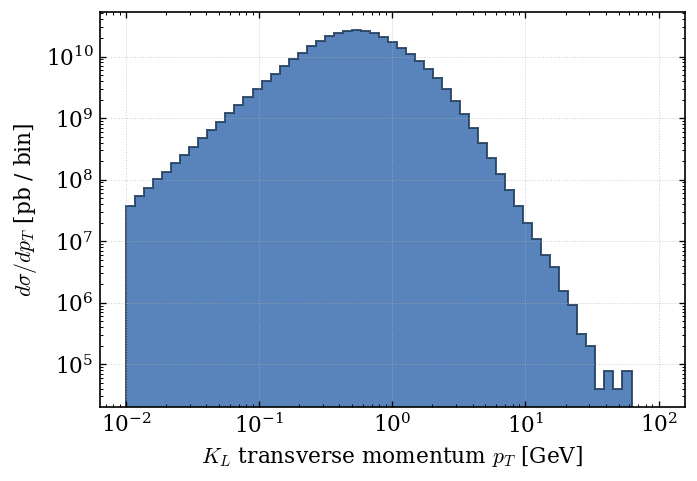

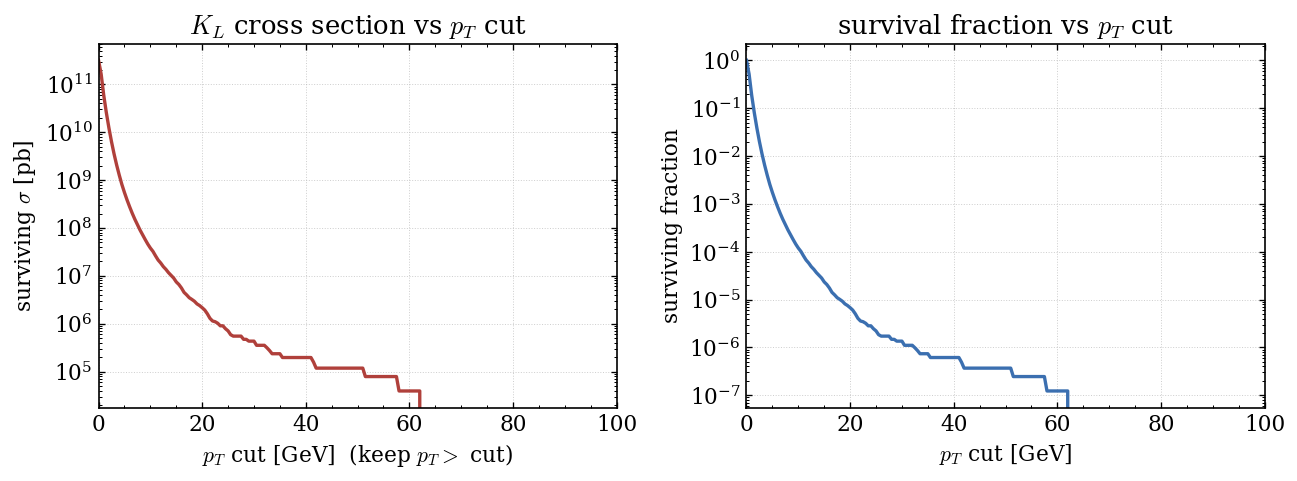

  pT cut         frac     sigma [pb]    N(K_L->gg) @ 312/fb
-----------------------------------------------------------
       0    1.000e+00      3.190e+11              5.445e+13
     0.5    5.160e-01      1.646e+11              2.810e+13
       1    1.865e-01      5.951e+10              1.016e+13
       2    3.869e-02      1.234e+10              2.106e+12
       5    1.729e-03      5.516e+08              9.414e+10
      10    1.195e-04      3.811e+07              6.505e+09
      20    6.774e-06      2.161e+06              3.688e+08
      30    1.355e-06      4.322e+05              7.376e+07
      40    6.158e-07      1.965e+05              3.353e+07
      50    3.695e-07      1.179e+05              2.012e+07
      60    1.232e-07      3.929e+04              6.706e+06
      70    0.000e+00      0.000e+00              0.000e+00


In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ---------- global publication style ----------
plt.rcParams.update({
    "font.size": 13,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# --- 1) pT distribution (as a cross section) ---
fig, ax = plt.subplots(figsize=(6, 4.2))
bins = np.logspace(-2, 2, 60)
ax.hist(soft_kl_pt, bins=bins, weights=np.full(len(soft_kl_pt), w_pb),
        histtype="stepfilled", color="#3b6fb0", edgecolor="#1f3b5c",
        alpha=0.85, linewidth=1.2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$K_L$ transverse momentum $p_T$ [GeV]")
ax.set_ylabel(r"$d\sigma/dp_T$ [pb / bin]")
ax.grid(True, which="major", ls=":", lw=0.6, alpha=0.6)
fig.tight_layout()
fig.savefig("kl_pt_distribution.pdf")
plt.show()

# --- 2) surviving cross section vs a pT > cut requirement ---
pt_sorted = np.sort(soft_kl_pt)
cuts = np.linspace(0, 100, 201)
n_above = len(pt_sorted) - np.searchsorted(pt_sorted, cuts, side="right")
sigma_above = n_above * w_pb          # pb
frac        = n_above / len(pt_sorted)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

ax[0].plot(cuts, sigma_above, color="#b0403b", lw=2.0)
ax[0].set_yscale("log")
ax[0].set_xlabel(r"$p_T$ cut [GeV]  (keep $p_T >$ cut)")
ax[0].set_ylabel(r"surviving $\sigma$ [pb]")
ax[0].set_title(r"$K_L$ cross section vs $p_T$ cut")
ax[0].grid(True, which="major", ls=":", lw=0.6, alpha=0.6)

ax[1].plot(cuts, frac, color="#3b6fb0", lw=2.0)
ax[1].set_yscale("log")
ax[1].set_xlabel(r"$p_T$ cut [GeV]")
ax[1].set_ylabel("surviving fraction")
ax[1].set_title(r"survival fraction vs $p_T$ cut")
ax[1].grid(True, which="major", ls=":", lw=0.6, alpha=0.6)

for a in ax:
    a.set_xlim(cuts.min(), cuts.max())

fig.tight_layout()
fig.savefig("kl_survival_vs_ptcut.pdf")
plt.show()

# --- 3) table of a few representative cuts ---
header = f"{'pT cut':>8} {'frac':>12} {'sigma [pb]':>14} {'N(K_L->gg) @ 312/fb':>22}"
print(header)
print("-" * len(header))
for c in [0, 0.5, 1, 2, 5, 10, 20, 30, 40, 50, 60, 70]:
    n = (soft_kl_pt > c).sum()
    s = n * w_pb
    N = s * L_FB * 1000 * BR_KL_GG
    print(f"{c:>8} {n/len(soft_kl_pt):>12.3e} {s:>14.3e} {N:>22.3e}")

In [17]:
soft_kl_sample  

,job,evt,pt,eta,phi,E,m,xProd_mm,yProd_mm,zProd_mm
0,900000,0,0.872447,7.988129,-0.460502,1285.019083,0.49761,2.636421e-06,-1.307861e-06,4.334710e-03
1,900000,0,0.748097,7.336079,2.199428,574.046594,0.49761,-6.777811e-08,9.322720e-08,8.844481e-05
2,900000,0,0.377424,8.801421,-1.563007,1253.740337,0.49761,3.392565e-09,-4.355256e-07,1.446790e-03
3,900000,1,0.967922,2.652627,1.093734,6.920038,0.49761,1.760640e-06,3.406265e-06,2.707228e-05
4,900000,1,0.315742,1.811549,2.793279,1.109769,0.49761,-3.137914e-07,1.139436e-07,9.942580e-07
...,...,...,...,...,...,...,...,...,...,...
8119241,900009,49998,0.374762,-7.414902,-2.387873,311.155414,0.49761,-3.658585e-07,-3.433836e-07,-4.165989e-04
8119242,900009,49998,0.223401,-4.933864,-0.100957,15.525692,0.49761,0.000000e+00,0.000000e+00,0.000000e+00
8119243,900009,49998,0.405693,-2.835739,-3.060250,3.504520,0.49761,0.000000e+00,0.000000e+00,0.000000e+00
8119244,900009,49999,0.735175,-1.144517,1.614486,1.365493,0.49761,-6.926993e-08,1.584473e-06,-2.238261e-06


In [18]:
print(soft_kl_sample["pt"].median(), soft_kl_sample["pt"].mean(), np.percentile(soft_kl_sample["pt"], [50, 90, 99]))

0.514875423907684 0.685437622669064 [0.51487542 1.36604207 3.08462979]


In [19]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('/home/export/sdurgut/scratch/alps/tracking_ALPs')
sys.path.insert(0, str(PROJECT_ROOT / 'analysis'))
sys.path.insert(0, str(PROJECT_ROOT))

from module_VBF import read_data
from scripts.analysis_helpers.file_helpers import ma_to_name
from module_VBF import raw_to_events

ma = 0.01                      # ALP mass in GeV
ma_name = ma_to_name(ma)       # -> 'grid_CMSRun3_vbf_ax_ma_0p0100GeV'

raw_events = read_data(
    ma_name,
    num=100000,                              # max events to load
    data_dir=str(PROJECT_ROOT / 'data/cmsrun3-csvs'),
)

print(f'Loaded {len(raw_events)} events')
print(raw_events[0])           # dict: {'j1','j2','a','g1','g2'} -> [E, px, py, pz]

Loaded 40000 events
{'a': array([ 19.89937337,   0.48013668,  15.96144109, -11.87378743]), 'g1': array([ 8.84086399,  0.20846049,  7.09078873, -5.27618569]), 'g2': array([11.05850938,  0.27167619,  8.87065235, -6.59760173]), 'j1': array([12.755635  , 11.51169056,  5.47991213,  0.39719178]), 'j2': array([ 56.03956733, -11.99182724, -21.44135322, -50.36762404])}


In [21]:
def load_events(gagg_list, ma, era='run3'):

    ma_name = ma_to_name(ma)
    raw_events = read_data(
        ma_name,
        num=100000,                              # max events to load
        data_dir=str(PROJECT_ROOT / 'data/cmsrun3-csvs'),
    )
    events = raw_to_events(raw_events, gaggs=gagg_list, ma=ma, era=era)
    print(f'Loaded {len(events)} events')
    return events

In [23]:
gagg_list= [1.00000000e-07, 1.44974067e-07, 2.10174801e-07, 3.04698957e-07, 4.41734470e-07, 6.40400427e-07, 9.28414545e-07, 1.34596032e-06, 1.95129342e-06, 2.82886943e-06, 4.10112707e-06, 5.94557071e-06, 8.61953566e-06, 1.24960914e-05, 1.81160919e-05, 2.62636353e-05, 3.80754602e-05, 5.51995432e-05, 8.00250228e-05, 1.16015530e-04, 1.68192432e-04, 2.43835410e-04, 3.53498111e-04, 5.12480588e-04, 7.42963951e-04, 1.07710506e-03, 1.56152301e-03, 2.26380341e-03, 3.28192787e-03, 4.75794431e-03, 6.89778538e-03, 1.00000000e-02]
era='run3'

## Soft Sample Kinematic Plots

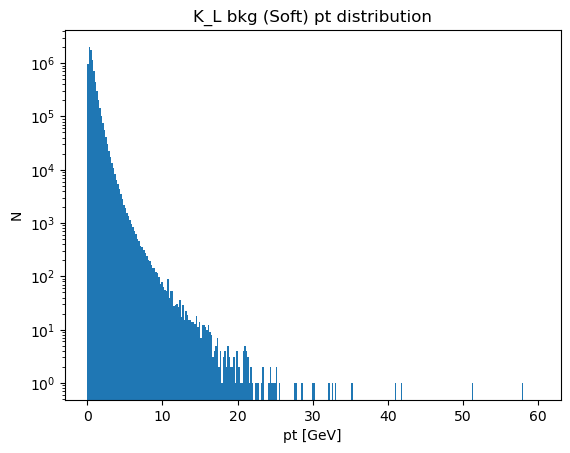

In [29]:
#make histogram of soft_kl_pt 
plt.hist(soft_kl_pt, bins=np.linspace(0, 60, 300))
plt.xlabel("pt [GeV]"); plt.ylabel("N")
plt.yscale("log")
plt.title("K_L bkg (Soft) pt distribution")
plt.show()


In [27]:
max(soft_kl_pt)

np.float64(62.30145868821651)

### M_a = 0.01 GeV ref

In [24]:
events_0p01 = load_events(gagg_list, 0.01)

Loaded 40000 events


In [19]:
xsec_gagg1e2_list = 180*np.ones(len(gagg_list))
n_a = 40000


In [20]:
config_no_cuts = calculate_n2g(filename='/home/export/sdurgut/scratch/alps/tracking_ALPs/results/run_config_nocuts/results_config_nocuts.csv', lumi=312)

In [21]:
config_no_cuts.shape

(32, 31)

In [22]:
import numpy as np
import scripts.plotting.param_space_plotting_utils as u   # (module needs sys.argv[1]=tracking_dir on import)

csv = "/home/export/sdurgut/scratch/alps/tracking_ALPs/results/run_config_nocuts/results_config_nocuts.csv"
masses = u.masses_from_results(csv)          # mass axis, from the CSV
N_sig  = u.calculate_n2g(csv, lumi=312)      # [gagg][mass] expected N(a->gg)

i05 = np.where(np.isclose(masses, 0.5))[0][0]   # find m_a = 0.5 GeV robustly
print("N(VBF a->gg) at 0.5 GeV, per gagg:", N_sig[:, i05])
print("compare to N(VBF K_L->gg) = 1.93e8")

N(VBF a->gg) at 0.5 GeV, per gagg: [5.61600000e-03 1.18034168e-02 2.48078078e-02 5.21397608e-02
 1.09584638e-01 2.30319296e-01 4.84073123e-01 1.01739972e+00
 2.13831784e+00 4.49420526e+00 9.44568701e+00 1.98524539e+01
 4.17248554e+01 8.76951318e+01 1.84313068e+02 3.87379628e+02
 8.14174360e+02 1.71118934e+03 3.59648880e+03 7.55891316e+03
 1.58869307e+04 3.33903251e+04 7.01780496e+04 1.47496576e+05
 3.10000635e+05 6.51543222e+05 1.36937967e+06 2.87809098e+06
 6.04902199e+06 1.27135199e+07 2.67206153e+07 5.61600000e+07]
compare to N(VBF K_L->gg) = 1.93e8


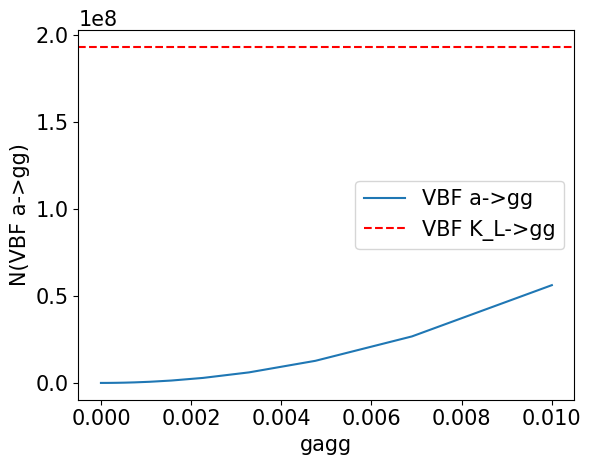

In [36]:
#plot N_sig vs gagg
plt.plot(gagg_list, N_sig[:, i05], label="VBF a->gg")
plt.xlabel("gagg")
plt.ylabel("N(VBF a->gg)")
#add one line at N(VBF K_L->gg) = 1.93e8
plt.axhline(1.93e8, color="red", linestyle="--", label="VBF K_L->gg")
plt.legend()
plt.show()


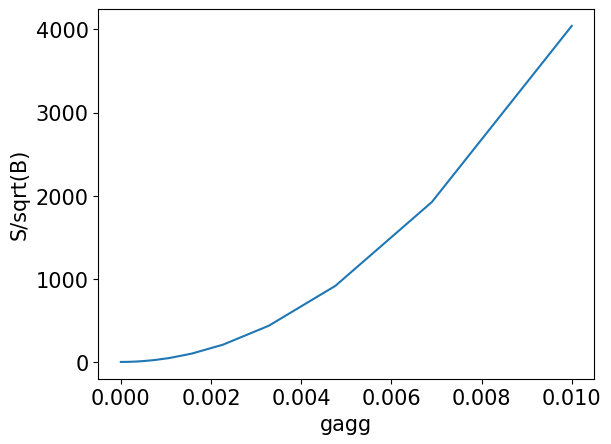

In [24]:
#plot S/sqrt(B) vs gagg
plt.plot(gagg_list, N_sig[:, i05]/np.sqrt(1.93e8))
plt.xlabel("gagg")
plt.ylabel("S/sqrt(B)")
plt.show()

In [25]:
#apply VBF cuts to events 
def apply_vbf_cuts(events):
    from scripts.analysis_helpers.kinematics_helpers import compute_mjj
    """Apply VBF cuts to events."""
    events_vbf = []
    leading_jet_pt_cut = 105.0
    sub_jet_pt_cut = 40.0
    mjj_cut = 720.0
    deta_cut = 3.0
    for ev in events:
        lead_jet_pt = max(ev['j1']['pt'], ev['j2']['pt'])
        sub_jet_pt = min(ev['j1']['pt'], ev['j2']['pt'])
        mjj = compute_mjj(ev)
        passes_lead_jet_pt = lead_jet_pt > leading_jet_pt_cut
        passes_sub_jet_pt = sub_jet_pt > sub_jet_pt_cut
        passes_mjj = mjj > mjj_cut
        passes_deta = abs(ev['j1']['eta'] - ev['j2']['eta']) > deta_cut
        if not (passes_lead_jet_pt & passes_sub_jet_pt & passes_mjj & passes_deta):
            continue
        events_vbf.append(ev)
    print('before cuts:', len(events))
    print('after cuts:', len(events_vbf))
    acc = len(events_vbf)/len(events)
    print('acceptance:', acc)
    return events_vbf, acc

events_0p01_vbf, acc_0p01 = apply_vbf_cuts(events_0p01)



before cuts: 40000
after cuts: 488
acceptance: 0.0122


In [26]:
events_1_GeV = load_events(gagg_list, 1)

Loaded 40000 events


In [1]:
events_1_GeV

NameError: name 'events_1_GeV' is not defined

In [27]:
events_1_GeV_vbf, acc_1_GeV = apply_vbf_cuts(events_1_GeV)

before cuts: 40000
after cuts: 477
acceptance: 0.011925


In [28]:
events_10_GeV = load_events(gagg_list, 10)

Loaded 40000 events


In [29]:
events_10_GeV_vbf, acc_10_GeV = apply_vbf_cuts(events_10_GeV)

before cuts: 40000
after cuts: 648
acceptance: 0.0162


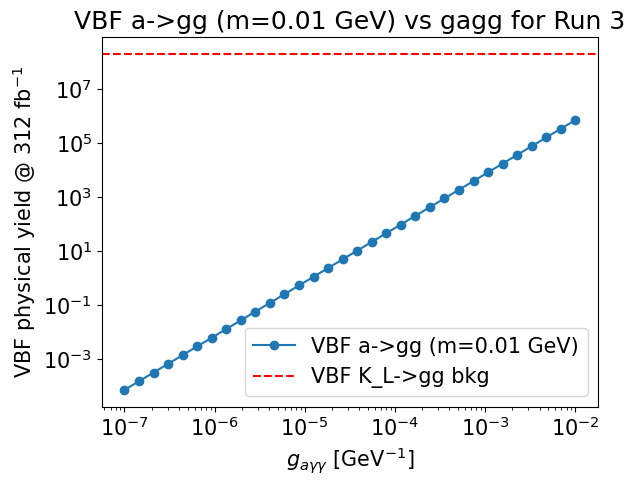

In [30]:
import numpy as np, matplotlib.pyplot as plt

n_vbf, n_a = 488, 40000          # your VBF survivors / generated (at m=0.5 GeV)
L, XSEC_1E2 = 312, 180.0         # fb^-1 ; pb at gagg=1e-2
acc = n_vbf / n_a

gagg = np.array([1.00000000e-07, 1.44974067e-07, 2.10174801e-07, 3.04698957e-07, 4.41734470e-07, 6.40400427e-07, 9.28414545e-07, 1.34596032e-06, 1.95129342e-06, 2.82886943e-06, 4.10112707e-06, 5.94557071e-06, 8.61953566e-06, 1.24960914e-05, 1.81160919e-05, 2.62636353e-05, 3.80754602e-05, 5.51995432e-05, 8.00250228e-05, 1.16015530e-04, 1.68192432e-04, 2.43835410e-04, 3.53498111e-04, 5.12480588e-04, 7.42963951e-04, 1.07710506e-03, 1.56152301e-03, 2.26380341e-03, 3.28192787e-03, 4.75794431e-03, 6.89778538e-03, 1.00000000e-02])

sigma = XSEC_1E2 * (gagg/1e-2)**2          # pb
N_vbf = acc * (L/1e-3) * sigma             # physical VBF yield

plt.plot(gagg, N_vbf, "o-", label="VBF a->gg (m=0.01 GeV)")
plt.axhline(1.93e8, color="red", ls="--", label="VBF K_L->gg bkg")   # optional
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"$g_{a\gamma\gamma}$ [GeV$^{-1}$]"); plt.ylabel("VBF physical yield @ 312 fb$^{-1}$")
plt.legend()
#title 
plt.title("VBF a->gg (m=0.01 GeV) vs gagg for Run 3")
plt.show()

In [31]:
pt_sig_0p01 = np.array([ev['a']['pt'] for ev in events_0p01_vbf])

In [38]:
hard_kl_sample = pd.read_csv("/home/export/sdurgut/scratch/alps/bkg/FORESEE/alp/kl_vbf_sample.csv")

In [39]:
pt_hard_kl = hard_kl_sample["kl_pt"].values

In [40]:
#save pt_hard_kl to numpy array 
pt_hard_kl = np.array(pt_hard_kl)
#save to disk 
np.save("hard_kl_sample_pt.npy", pt_hard_kl)


In [37]:
pt_hard_kl

NameError: name 'pt_hard_kl' is not defined

In [39]:
def eff(pt, cuts):                       # fraction with pt > cut
    s = np.sort(pt)
    return (len(s) - np.searchsorted(s, cuts, side="right")) / len(s)

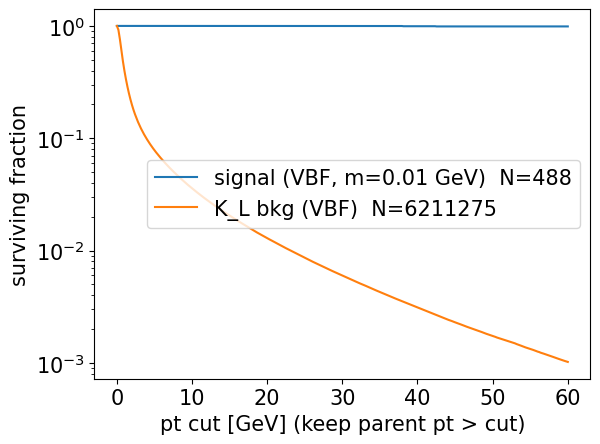

In [41]:
cuts = np.linspace(0, 60, 300)
plt.plot(cuts, eff(pt_sig_0p01, cuts), label=f"signal (VBF, m=0.01 GeV)  N={len(pt_sig_0p01)}")
plt.plot(cuts, eff(pt_hard_kl, cuts), label=f"K_L bkg (VBF)  N={len(pt_hard_kl)}")
plt.yscale("log")
plt.xlabel("pt cut [GeV] (keep parent pt > cut)"); plt.ylabel("surviving fraction")
plt.legend(); plt.show()

In [36]:
#plot bkg pt distribution
plt.hist(pt_hard_kl, bins=np.linspace(0, 60, 300))
plt.xlabel("pt [GeV]"); plt.ylabel("N")
plt.title("K_L bkg (VBF) pt distribution")
plt.show()
#plot signal pt distribution
plt.hist(pt_sig_0p01, bins=np.linspace(0, 60, 300))

NameError: name 'pt_hard_kl' is not defined

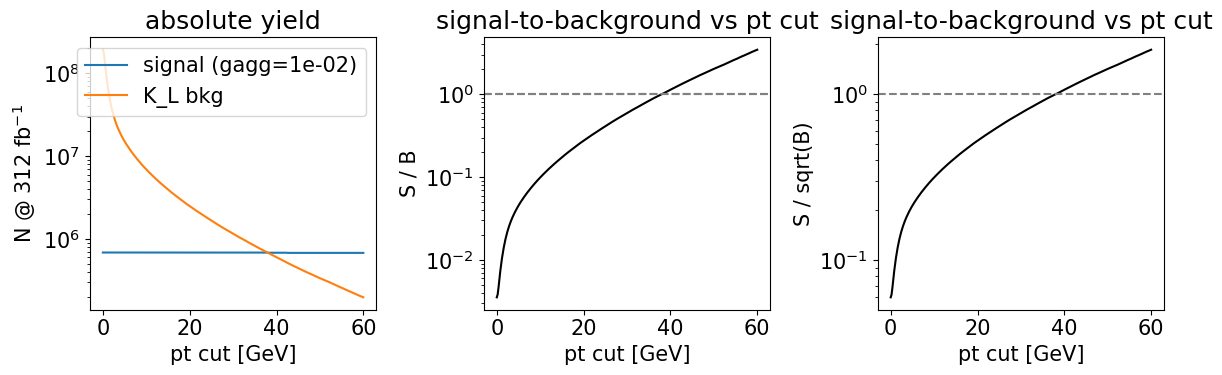

no cut: S=6.85e+05 B=1.93e+08 S/B=3.55e-03


In [ ]:
GAGG_REF = 1.0e-2                      # GeV^-1
n_a, L, XSEC_1E2 = 40000, 312, 180.0

N_sig_VBF = (len(pt_sig_0p01)/n_a) * (L/1e-3) * XSEC_1E2*(GAGG_REF/1e-2)**2  # VBF signal yield @0.5 GeV
N_bkg_VBF = 1.93e8                                                      # VBF K_L->gg @0.5 GeV

cuts  = np.linspace(0, 60, 300)
N_sig = N_sig_VBF * eff(pt_sig_0p01, cuts)
N_bkg = N_bkg_VBF * eff(pt_bkg, cuts)

fig, ax = plt.subplots(1, 3, figsize=(12,4))
ax[0].plot(cuts, N_sig, label=f"signal (gagg={GAGG_REF:.0e})")
ax[0].plot(cuts, N_bkg, label="K_L bkg")
ax[0].set_yscale("log"); ax[0].set_xlabel("pt cut [GeV]"); ax[0].set_ylabel("N @ 312 fb$^{-1}$")
ax[0].legend(); ax[0].set_title("absolute yield")

with np.errstate(divide="ignore", invalid="ignore"):
    sb = np.where(N_bkg>0, N_sig/N_bkg, np.nan)
ax[1].plot(cuts, sb, color="k"); ax[1].axhline(1, ls="--", color="gray")
#draw a horizontal line at 1e0
ax[1].axhline(1e0, ls="--", color="gray")
ax[1].set_yscale("log"); ax[1].set_xlabel("pt cut [GeV]"); ax[1].set_ylabel("S / B")
ax[1].set_title("signal-to-background vs pt cut")
#also plot s/sqrt(b) vs pt cut
ax[2].plot(cuts, np.sqrt(N_sig/N_bkg), color="k"); ax[2].axhline(1, ls="--", color="gray")
ax[2].set_yscale("log"); ax[2].set_xlabel("pt cut [GeV]"); ax[2].set_ylabel("S / sqrt(B)")
ax[2].set_title("signal-to-background vs pt cut")
plt.tight_layout(); plt.show()

print(f"no cut: S={N_sig[0]:.2e} B={N_bkg[0]:.2e} S/B={N_sig[0]/N_bkg[0]:.2e}")

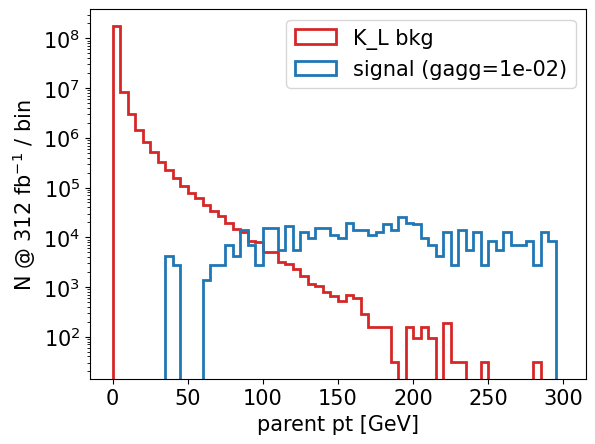

: 

In [ ]:
w_bkg = np.full(len(pt_bkg), N_bkg_VBF/len(pt_bkg))
w_sig = np.full(len(pt_sig_0p01), N_sig_VBF/len(pt_sig_0p01))


bins = np.linspace(0, 300, 61)
plt.hist(pt_bkg, bins=bins, weights=w_bkg, histtype="step", lw=2, color="tab:red",  label="K_L bkg")
plt.hist(pt_sig_0p01, bins=bins, weights=w_sig, histtype="step", lw=2, color="tab:blue", label=f"signal (gagg={GAGG_REF:.0e})")
plt.yscale("log")
plt.xlabel("parent pt [GeV]"); plt.ylabel("N @ 312 fb$^{-1}$ / bin")
plt.legend(); plt.show()